<div style="background-color:#f8f9fa;
    padding:20px;
    border:2px solid #360084;
    border-radius:8px;
    margin:10px 0;">
    <div style="background-color:#fafdf0;
        line-height:2;
        text-align:center;
        border:2px solid #360084;
        padding:15px;
        border-radius:5px;">
        <div style="color:#008B8B;
            font-size:24pt;
            font-weight:700;">
            Linear Regression Residual Diagnosis: Systematic Pattern
        </div>
    </div> 
    <div style="margin-top:15px; padding:10px;">
        <strong>Course:</strong> Econometrics<br>
        <strong>Topic:</strong> Linear Regression Residual Analysis<br>
        <strong>Instructor:</strong> Dr. Saad Laouadi<br>
        <strong>Objective:</strong> Using synthetic data to show systematic pattern in linear regression residuals.
    </div>
</div>

---

In [1]:
# ====================================================== #
#            Environment Setup
# ====================================================== #

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (15, 12)
sns.set_style("whitegrid")

print("*"*52)
print("Environment Setup".center(52))
%reload_ext watermark
%watermark -iv -v -ud -a "Dr. Saad Laouadi"
print("*"*52)

****************************************************
                 Environment Setup                  
Author: Dr. Saad Laouadi

Last updated: 2025-06-15

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 9.1.0

numpy      : 2.3.0
matplotlib : 3.10.0
scipy      : 1.15.3
seaborn    : 0.13.2
statsmodels: 0.14.4

****************************************************


In [2]:
print("=== SYNTHETIC DATA FOR DIAGNOSTIC PATTERNS ===")
print("Demonstrating Good vs Bad Patterns in Regression Diagnostics")

# Set random seed for reproducibility
np.random.seed(42)

# Generate sample size
n = 200
x = np.linspace(1, 10, n)

#==============================================================================
# 1. GOOD MODEL - All assumptions satisfied
#==============================================================================

# Good model: Linear relationship with constant variance
y_good = 2 + 3*x + np.random.normal(0, 1, n)
fitted_good = 2 + 3*x
residuals_good = y_good - fitted_good

print(f"\n1. GOOD MODEL: Linear relationship, constant variance")
print(f"   Model: Y = 2 + 3*X + ε, where ε ~ N(0,1)")

#==============================================================================
# 2. SYSTEMATIC PATTERNS - Clear trend in residuals
#==============================================================================

# Create multiple systematic patterns
# Pattern A: Sine wave pattern (cyclical)
error_cyclical = 2 * np.sin(x) + np.random.normal(0, 0.5, n)
y_cyclical = 2 + 3*x + error_cyclical
fitted_cyclical = 2 + 3*x
residuals_cyclical = y_cyclical - fitted_cyclical

# Pattern B: Strong outliers creating systematic pattern
error_outliers = np.random.normal(0, 0.5, n)
# Add systematic outliers every 20 points
outlier_indices = np.arange(10, n, 20)
error_outliers[outlier_indices] += 4 * np.sin(x[outlier_indices])
y_outliers = 2 + 3*x + error_outliers
fitted_outliers = 2 + 3*x
residuals_outliers = y_outliers - fitted_outliers

print(f"\n4. SYSTEMATIC PATTERNS:")
print(f"   Pattern A: Cyclical errors (sine wave)")
print(f"   Pattern B: Systematic outliers")
print(f"   Problem: Clear non-random patterns in residuals")

=== SYNTHETIC DATA FOR DIAGNOSTIC PATTERNS ===
Demonstrating Good vs Bad Patterns in Regression Diagnostics

1. GOOD MODEL: Linear relationship, constant variance
   Model: Y = 2 + 3*X + ε, where ε ~ N(0,1)

4. SYSTEMATIC PATTERNS:
   Pattern A: Cyclical errors (sine wave)
   Pattern B: Systematic outliers
   Problem: Clear non-random patterns in residuals


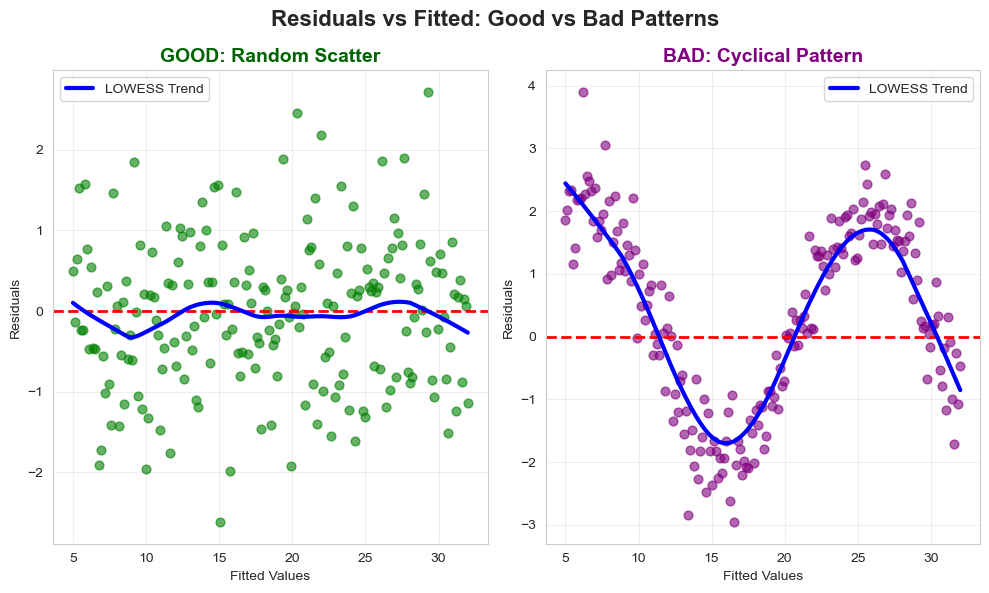

In [3]:
#==============================================================================
# VISUALIZATION: Residuals vs Fitted Patterns
#==============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

# Helper function to add lowess line
def add_lowess_line(ax, x_vals, y_vals, color='blue'):
    lowess_line = lowess(y_vals, x_vals, frac=0.3)
    ax.plot(lowess_line[:, 0], lowess_line[:, 1], color=color, linewidth=3, label='LOWESS Trend')

# Plot 1: Good Model
ax1.scatter(fitted_good, residuals_good, alpha=0.6, s=40, color='green')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
add_lowess_line(ax1, fitted_good, residuals_good)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('GOOD: Random Scatter', fontsize=14, fontweight='bold', color='darkgreen')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 4: Systematic patterns
ax2.scatter(fitted_cyclical, residuals_cyclical, alpha=0.6, s=40, color='purple')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
add_lowess_line(ax2, fitted_cyclical, residuals_cyclical, 'blue')
ax2.set_xlabel('Fitted Values')
ax2.set_ylabel('Residuals')
ax2.set_title('BAD: Cyclical Pattern', fontsize=14, fontweight='bold', color='purple')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle('Residuals vs Fitted: Good vs Bad Patterns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

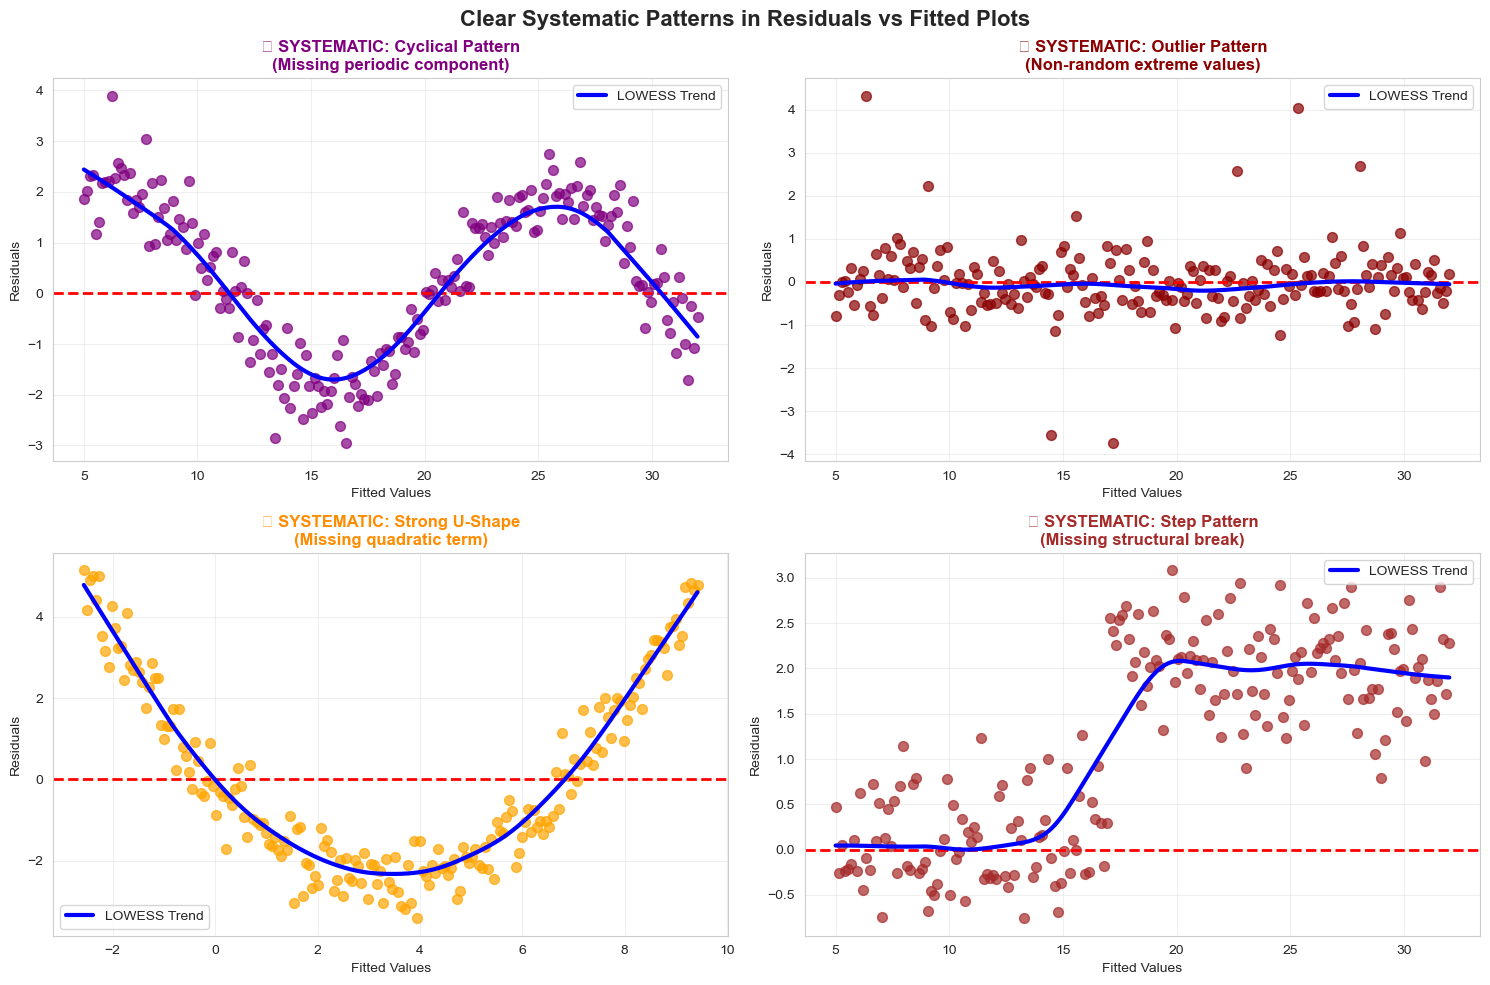

In [4]:
#==============================================================================
# ADDITIONAL SYSTEMATIC PATTERNS DEMONSTRATION
#==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Pattern 1: Cyclical (sine wave)
ax1 = axes[0, 0]
ax1.scatter(fitted_cyclical, residuals_cyclical, alpha=0.7, s=50, color='purple')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
add_lowess_line(ax1, fitted_cyclical, residuals_cyclical, 'blue')
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('❌ SYSTEMATIC: Cyclical Pattern\n(Missing periodic component)', fontsize=12, fontweight='bold', color='purple')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Pattern 2: Systematic outliers
ax2 = axes[0, 1]
ax2.scatter(fitted_outliers, residuals_outliers, alpha=0.7, s=50, color='darkred')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
add_lowess_line(ax2, fitted_outliers, residuals_outliers, 'blue')
ax2.set_xlabel('Fitted Values')
ax2.set_ylabel('Residuals')
ax2.set_title('❌ SYSTEMATIC: Outlier Pattern\n(Non-random extreme values)', fontsize=12, fontweight='bold', color='darkred')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Pattern 3: U-shaped pattern (stronger non-linearity)
x_u = np.linspace(-3, 3, n)
y_u_true = 1 + 2*x_u + 0.8*x_u**2 + np.random.normal(0, 0.5, n)
# Fit linear (wrong!)
slope = np.sum((x_u - np.mean(x_u))*(y_u_true - np.mean(y_u_true))) / np.sum((x_u - np.mean(x_u))**2)
fitted_u = np.mean(y_u_true) + slope * x_u
residuals_u = y_u_true - fitted_u

ax3 = axes[1, 0]
ax3.scatter(fitted_u, residuals_u, alpha=0.7, s=50, color='orange')
ax3.axhline(y=0, color='red', linestyle='--', linewidth=2)
add_lowess_line(ax3, fitted_u, residuals_u, 'blue')
ax3.set_xlabel('Fitted Values')
ax3.set_ylabel('Residuals')
ax3.set_title('❌ SYSTEMATIC: Strong U-Shape\n(Missing quadratic term)', fontsize=12, fontweight='bold', color='darkorange')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Pattern 4: Step function pattern
x_step = np.linspace(1, 10, n)
step_effect = np.where(x_step < 5, 0, 2)  # Jump at x=5
y_step = 2 + 3*x_step + step_effect + np.random.normal(0, 0.5, n)
fitted_step = 2 + 3*x_step  # Linear fit (missing step)
residuals_step = y_step - fitted_step

ax4 = axes[1, 1]
ax4.scatter(fitted_step, residuals_step, alpha=0.7, s=50, color='brown')
ax4.axhline(y=0, color='red', linestyle='--', linewidth=2)
add_lowess_line(ax4, fitted_step, residuals_step, 'blue')
ax4.set_xlabel('Fitted Values')
ax4.set_ylabel('Residuals')
ax4.set_title('❌ SYSTEMATIC: Step Pattern\n(Missing structural break)', fontsize=12, fontweight='bold', color='brown')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.suptitle('Clear Systematic Patterns in Residuals vs Fitted Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()